In [1]:
import matplotlib.pyplot as plt
import os
from ast import literal_eval as liteval
import math as m
import file_utils

plt.rc('text', usetex=True)

colors = ["k", "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

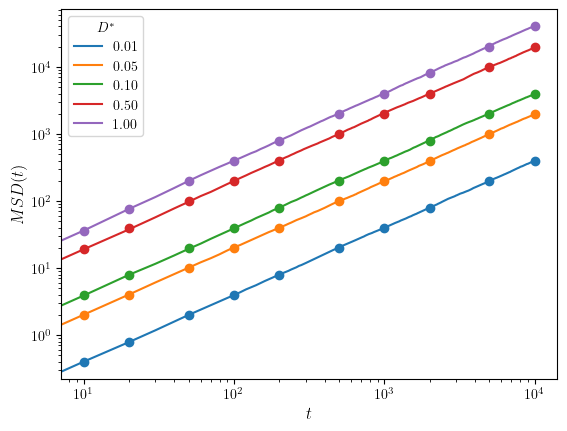

In [24]:
# Comparison between MSD calculations using MSD.cpp with LAMMPS output from 5 datasets

fig, ax = plt.subplots()

# Plotting LAMMPS output MSD data
dt = 5e-5
frameW = 2e5

dirpath = "//media/ashwin/One Touch/ashwin_md/msd_benchmarks/Oct2024"
imgpath = "/home/ashwin/Desktop/ashwin_md/LD/LD-cpp/imgs/Mar2025"
contents = os.listdir(dirpath)

files = []
for fname in contents:
    if(fname.find("lmp_D_") >= 0):
        files.append(fname)

for i in range(len(files)):
    fpath = os.path.join(dirpath, files[i], "msd.dat")
    [[frame, msd], _] = file_utils.readData(fpath, 1)
    
    time = [j*dt*frameW for j in frame]
    ax.loglog(time, msd, label = r"${d}$".format(d = files[i].removeprefix("lmp_D_")))

    fpath = os.path.join(dirpath, files[i], "msd_cpp.dat")
    [[step, msd], _] = file_utils.readData(fpath, 1)
    
    time = [j*dt for j in step]
    ax.loglog(time, msd, "o", color = colors[i])

ax.set_xlabel(r"$t$", fontsize = 12)
ax.set_ylabel(r"$MSD (t)$", fontsize = 12)
ax.legend(title = r"$D^*$")
#fig.savefig(os.path.join(imgpath, "MSD_benchmarks1.png"), dpi = 500, bbox_inches = "tight")

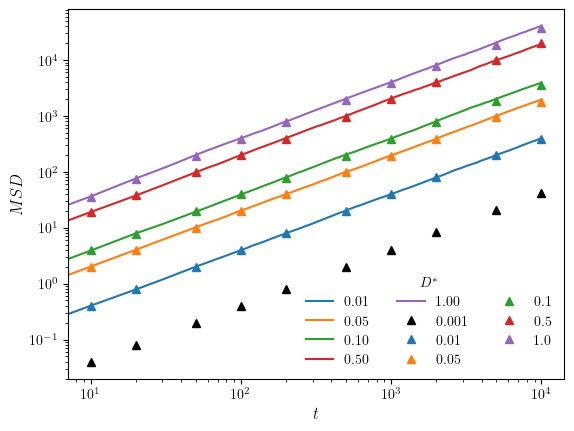

In [5]:
fig, ax = plt.subplots()

# Plotting LAMMPS output MSD data
dt = 5e-5
frameW = 2e5

dirpath = "//media/ashwin/One Touch/ashwin_md/msd_benchmarks/Oct2024"
imgpath = "/home/ashwin/Desktop/ashwin_md/LD/LD-cpp/imgs/Mar2025"
contents = os.listdir(dirpath)

files = []
for fname in contents:
    if(fname.find("lmp_D_") >= 0):
        files.append(fname)

for i in range(len(files)):
    fpath = os.path.join(dirpath, files[i], "msd.dat")
    [[frame, msd], _] = file_utils.readData(fpath, 1)
    
    time = [j*dt*frameW for j in frame]
    ax.loglog(time, msd, label = r"${d}$".format(d = files[i].removeprefix("lmp_D_")))

nr_list = [273, 274, 275, 276, 277, 278]
D = ["0.001", "0.01", "0.05", "0.1", "0.5", "1.0"]

dirpath = dirpath.removesuffix("Oct2024")
for i in range(len(nr_list)):
    fpath = os.path.join(dirpath, "Mar2025", "Data{nr}".format(nr = nr_list[i]), "msd.dat")
    [[step, msd], _] = file_utils.readData(fpath, 1)

    time = [j*dt for j in step]
    ax.loglog(time, msd, "^", color = colors[i], label = r"${d}$".format(d = D[i]))

ax.set_xlabel(r"$t$", fontsize = 12)
ax.set_ylabel(r"$MSD$", fontsize = 12)
ax.legend(title = r"$D^*$", ncol = 3, frameon = False)
#fig.savefig(os.path.join(imgpath, "MSD_benchmarks2.png"), dpi = 500, bbox_inches = "tight")

2) Comparison of MSD values between simulated trajectories (cpp code) and theoretical predictions. The integrator assumes $~\{\sigma, D, k_BT\}~$ as basis units to non-dimensionalize the equation of motion. In this unit system, the friction coefficient $~\gamma = D/k_BT = 1.0~$ and the solvent viscosity is fixed. The Mean-Squared Displacement (MSD) is given as,

$$ <|\textbf{r}(t) - \textbf{r}(0)|^2> = 4t$$<br>
The dimensionless mass of the particle $m^*$ is a free parameter and fixes the inertial time $~\tau_{in}^* = mD/k_BT = m^*~$. The data represent the following system parameters:<br>

<center>
    
| $nr$ | $t$ | $dt$ | $frameW$ | $m^*$ |
| :----: | :----: | :----: | :----: | :----: |
| 268 | 10000 | 5e-4 | 10000 | 1.0 |
| 269 | 10000 | 5e-4 | 10000 | 1.0e-2 |
| 270 | 10000 | 5e-4 | 10000 | 1.0e-4 |
| 271 | 4000 | 1e-4 | 10000 | 1.0e-4 |
| 272 | 100 | 1e-6 | 10000 | 1.0e-6 |

</center><br>

Data 270 shows significant deviation from the theoretical results because the integration timestep $dt$ is larger than the inertial time. Hence, one must choose $dt$ such that it is smaller than any other timescale relevant to the problem. 

t = [5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0, 2500.0, 5000.0]
t = [5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0, 2500.0, 5000.0]
t = [5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0, 2500.0, 5000.0]
t = [1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0]
t = [0.01, 0.02, 0.049999999999999996, 0.09999999999999999, 0.19999999999999998, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0]


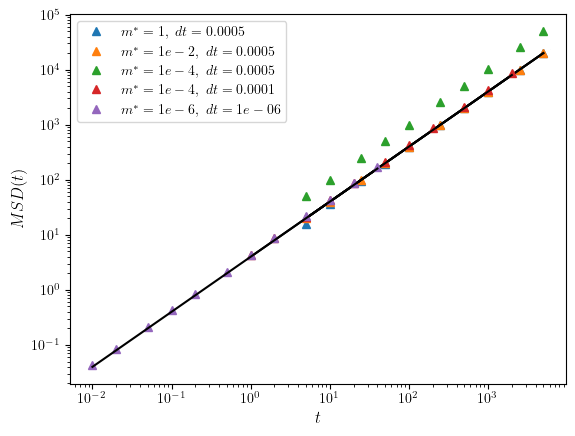

In [33]:
# Compare the MSD values from a set of simulations against theoretical predictions

nr_list = [268, 269, 270, 271, 272]
m = ["1", "1e-2", "1e-4", "1e-4", "1e-6"]
dt = [5e-4, 5e-4, 5e-4, 1e-4, 1e-6]

fig, ax = plt.subplots()

for i in range(len(nr_list)):
    
    fpath = "//media/ashwin/One Touch/ashwin_md/msd_benchmarks/Mar2025/Data{nr}/msd.dat".format(nr = nr_list[i])
    [[step, msd], _] = file_utils.readData(fpath, 1)
    time = [j*dt[i] for j in step]
    print("t =", time)

    msd_th = [4*i for i in time]
    ax.loglog(time, msd, "^", color = colors[i], label = r"$m^* = {m}, ~dt = {dtime}$".format(m = m[i], dtime = str(dt[i])))
    ax.loglog(time, msd_th, "k-")

ax.set_xlabel(r"$t$", fontsize = 12)
ax.set_ylabel(r"$MSD (t)$", fontsize = 12)
ax.legend()
fig.savefig(os.path.join(imgpath, "MSD_benchmarks3.png"), dpi = 500, bbox_inches = "tight")